# 04 — Classification Model: Insulation Failure Prediction
### PMSM Winding Process — Quality Prediction Project
---
**Goal:** Predict whether a winding sample will fail insulation quality control.  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Metrics:** ROC-AUC · F1 · Precision · Recall · Confusion Matrix


## 1. Imports & Config

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('04_Classification.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\PMSM Winding Project\pmsm-winding-quality-prediction\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    classification_report, average_precision_score,
    precision_recall_curve
)
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 12,
})

os.makedirs('../results/plots', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


## 2. Load Data

In [3]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

with open('../src/feature_list.txt') as f:
    FEATURES = [line.strip() for line in f.readlines()]

TARGET = 'insulation_failure'

X_train = train[FEATURES];  y_train = train[TARGET]
X_val   = val[FEATURES];    y_val   = val[TARGET]
X_test  = test[FEATURES];   y_test  = test[TARGET]

print(f"Train : {X_train.shape}  failure rate: {y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape}    failure rate: {y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape}   failure rate: {y_test.mean()*100:.1f}%")


Train : (350, 44)  failure rate: 25.1%
Val   : (75, 44)    failure rate: 25.3%
Test  : (75, 44)   failure rate: 25.3%


## 3. Class Balance Check

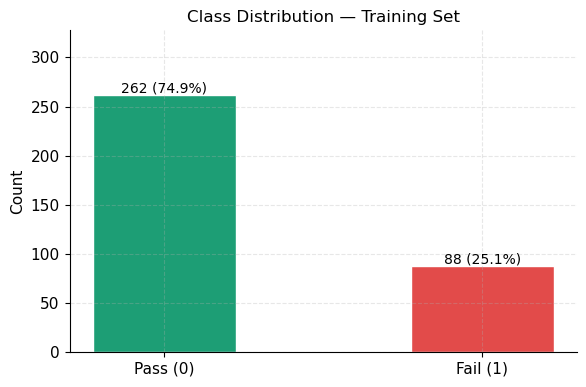

Class ratio (pass:fail) = 3.0:1
→ Using scale_pos_weight in XGBoost to handle imbalance


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts().sort_index()
bars = ax.bar(['Pass (0)', 'Fail (1)'], counts.values,
              color=['#1D9E75', '#E24B4A'], edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val} ({val/len(y_train)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class Distribution — Training Set')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.25)
plt.tight_layout()
plt.savefig('../results/plots/16_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts[0] / counts[1]
print(f"Class ratio (pass:fail) = {ratio:.1f}:1")
print("→ Using scale_pos_weight in XGBoost to handle imbalance")


## 4. Define Models

In [5]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

clf_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=3,
        class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=SEED, verbosity=0, n_jobs=-1,
        eval_metric='logloss'),
}
print(f"scale_pos_weight for XGBoost: {scale_pos:.2f}")
print("Models defined:")
for name in clf_models:
    print(f"  {name}")


scale_pos_weight for XGBoost: 2.98
Models defined:
  Logistic Regression
  Random Forest
  XGBoost


## 5. Train & Evaluate All Models

In [6]:
def evaluate_clf(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    preds = model.predict(X_te)
    return {
        'AUC':       roc_auc_score(y_te, proba),
        'F1':        f1_score(y_te, preds),
        'Precision': precision_score(y_te, preds, zero_division=0),
        'Recall':    recall_score(y_te, preds),
        'Accuracy':  accuracy_score(y_te, preds),
        'proba':     proba,
        'preds':     preds,
    }

clf_results = {}
print(f"{'Model':<22} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'Acc':>7}")
print("-" * 58)

for name, model in clf_models.items():
    res = evaluate_clf(model, X_train, y_train, X_val, y_val)
    clf_results[name] = res
    print(f"{name:<22} {res['AUC']:>7.4f} {res['F1']:>7.4f} "
          f"{res['Precision']:>7.4f} {res['Recall']:>7.4f} {res['Accuracy']:>7.4f}")


Model                      AUC      F1    Prec     Rec     Acc
----------------------------------------------------------
Logistic Regression     0.6729  0.4583  0.3793  0.5789  0.6533
Random Forest           0.6429  0.2759  0.4000  0.2105  0.7200
XGBoost                 0.6513  0.4000  0.4375  0.3684  0.7200


## 6. ROC Curves — All Models

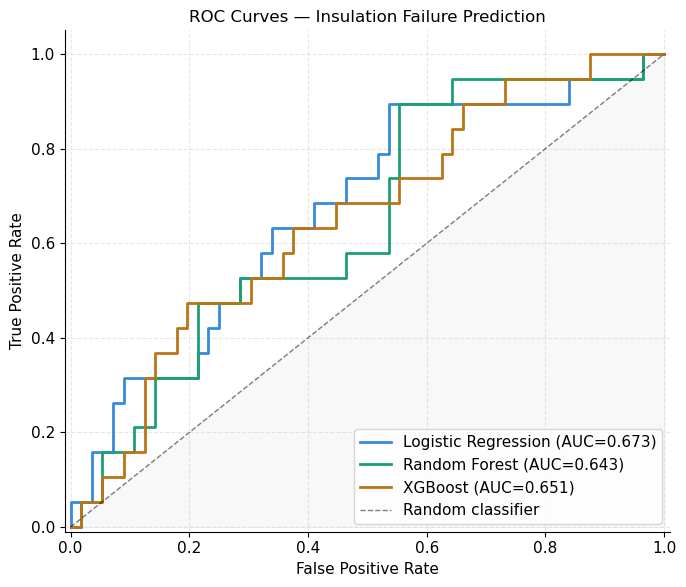

Saved: 17_roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#378ADD', '#1D9E75', '#BA7517']
for (name, res), color in zip(clf_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC={res['AUC']:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Insulation Failure Prediction')
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.savefig('../results/plots/17_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 17_roc_curves.png")


## 7. Precision-Recall Curves

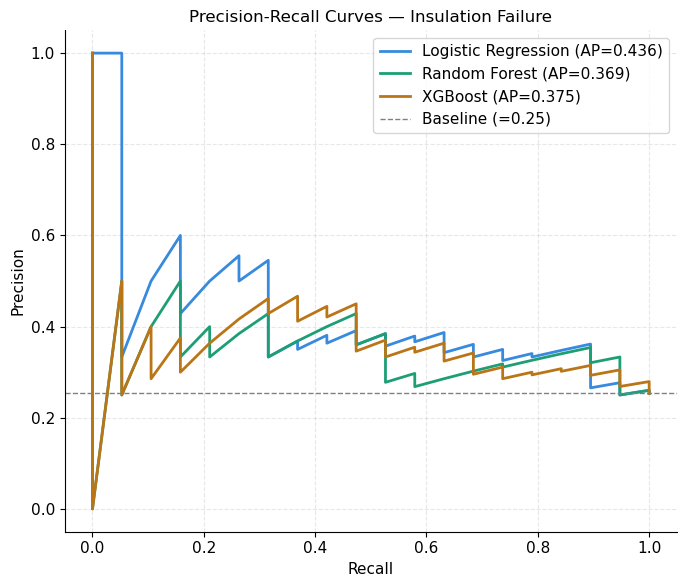

Saved: 18_precision_recall.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#378ADD', '#1D9E75', '#BA7517']

for (name, res), color in zip(clf_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_val, res['proba'])
    ap = average_precision_score(y_val, res['proba'])
    ax.plot(rec, prec, lw=2, color=color, label=f"{name} (AP={ap:.3f})")

baseline = y_val.mean()
ax.axhline(baseline, color='gray', lw=1, linestyle='--',
           label=f'Baseline (={baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Insulation Failure')
ax.legend()
plt.tight_layout()
plt.savefig('../results/plots/18_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 18_precision_recall.png")


## 8. Confusion Matrices — All Models

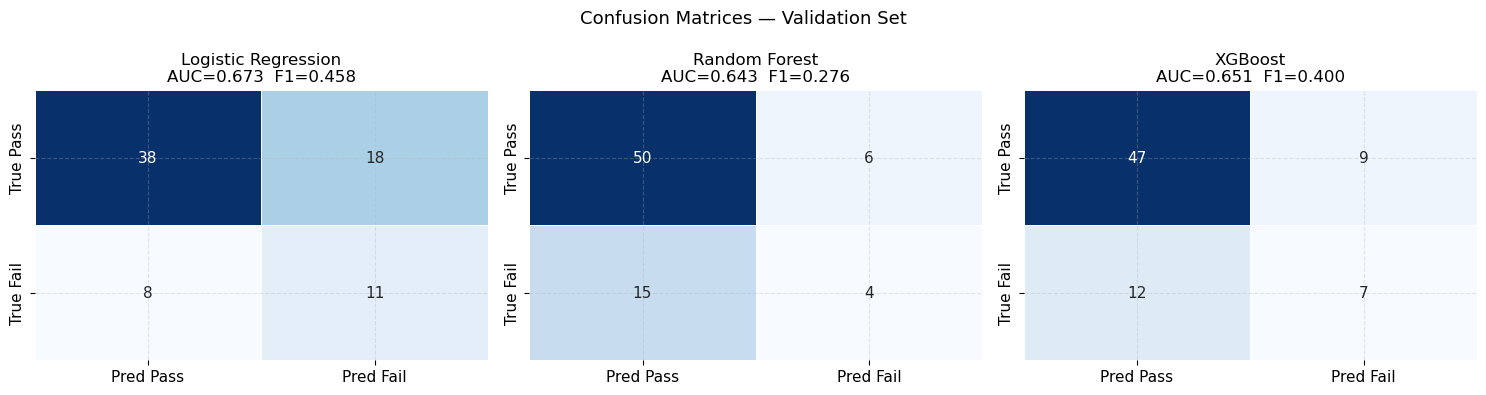

Saved: 19_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Validation Set', fontsize=13)

for ax, (name, res) in zip(axes, clf_results.items()):
    cm = confusion_matrix(y_val, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Pred Pass', 'Pred Fail'],
                yticklabels=['True Pass', 'True Fail'],
                linewidths=0.5)
    ax.set_title(f"{name}\nAUC={res['AUC']:.3f}  F1={res['F1']:.3f}")

plt.tight_layout()
plt.savefig('../results/plots/19_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 19_confusion_matrices.png")


## 9. Cross-Validation (Stratified 5-Fold)

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X_tv = pd.concat([X_train, X_val]).reset_index(drop=True)
y_tv = pd.concat([y_train, y_val]).reset_index(drop=True)

print("Stratified 5-Fold CV Results:")
print(f"{'Model':<22} {'AUC mean':>10} {'AUC std':>9} {'F1 mean':>9} {'F1 std':>8}")
print("-" * 62)

cv_clf_results = {}
for name, model in clf_models.items():
    auc_scores = cross_val_score(model, X_tv, y_tv, cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_tv, y_tv, cv=skf, scoring='f1',      n_jobs=-1)
    cv_clf_results[name] = {'auc': auc_scores, 'f1': f1_scores}
    print(f"{name:<22} {auc_scores.mean():>10.4f} {auc_scores.std():>9.4f} "
          f"{f1_scores.mean():>9.4f} {f1_scores.std():>8.4f}")


Stratified 5-Fold CV Results:
Model                    AUC mean   AUC std   F1 mean   F1 std
--------------------------------------------------------------
Logistic Regression        0.6642    0.0558    0.4493   0.0400
Random Forest              0.6570    0.0548    0.2765   0.1072
XGBoost                    0.6235    0.0443    0.2157   0.0968


## 10. CV Score Distribution Plot

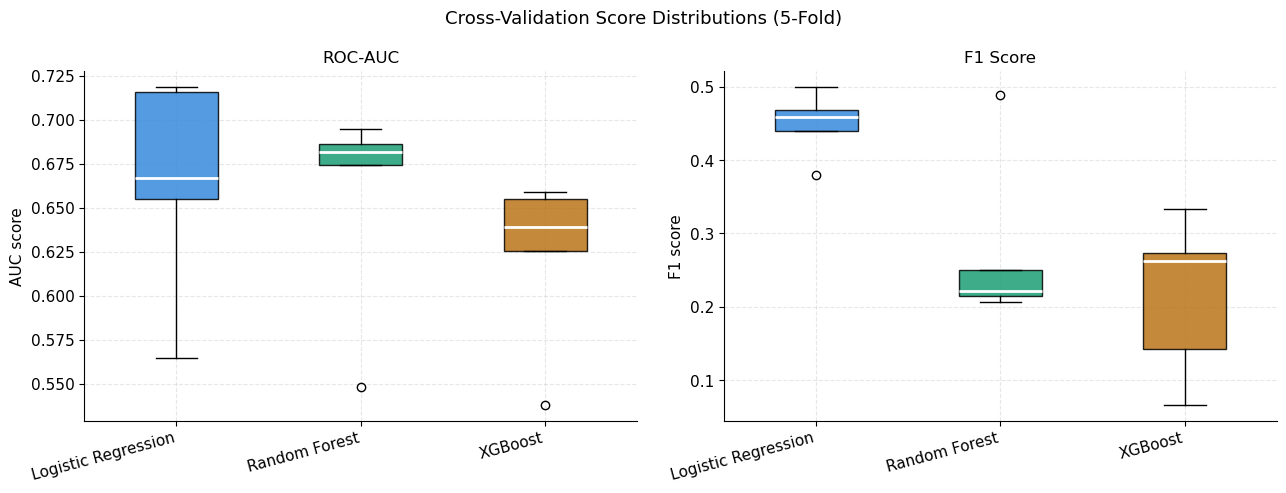

Saved: 20_cv_score_distributions.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Validation Score Distributions (5-Fold)', fontsize=13)

colors = ['#378ADD', '#1D9E75', '#BA7517']
names  = list(clf_models.keys())

# AUC
ax = axes[0]
data = [cv_clf_results[n]['auc'] for n in names]
bp = ax.boxplot(data, patch_artist=True, widths=0.45,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_title('ROC-AUC')
ax.set_ylabel('AUC score')

# F1
ax = axes[1]
data = [cv_clf_results[n]['f1'] for n in names]
bp = ax.boxplot(data, patch_artist=True, widths=0.45,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_title('F1 Score')
ax.set_ylabel('F1 score')

plt.tight_layout()
plt.savefig('../results/plots/20_cv_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 20_cv_score_distributions.png")


## 11. Final Evaluation on Hold-Out Test Set

In [12]:
best_clf_name = max(clf_results, key=lambda m: clf_results[m]['AUC'])
best_clf      = clf_models[best_clf_name]

# Retrain on train + val
best_clf.fit(X_tv, y_tv)
test_proba = best_clf.predict_proba(X_test)[:, 1]
test_preds = best_clf.predict(X_test)

print(f"BEST MODEL: {best_clf_name}")
print(f"{'='*45}")
print(f"  Test AUC       : {roc_auc_score(y_test, test_proba):.4f}")
print(f"  Test F1        : {f1_score(y_test, test_preds):.4f}")
print(f"  Test Precision : {precision_score(y_test, test_preds):.4f}")
print(f"  Test Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"  Test Accuracy  : {accuracy_score(y_test, test_preds):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Pass', 'Fail']))

joblib.dump(best_clf, '../src/best_classifier.pkl')
print(f"Best classifier saved: ../src/best_classifier.pkl")


BEST MODEL: Logistic Regression
  Test AUC       : 0.7566
  Test F1        : 0.4783
  Test Precision : 0.4074
  Test Recall    : 0.5789
  Test Accuracy  : 0.6800

Classification Report:
              precision    recall  f1-score   support

        Pass       0.83      0.71      0.77        56
        Fail       0.41      0.58      0.48        19

    accuracy                           0.68        75
   macro avg       0.62      0.65      0.62        75
weighted avg       0.73      0.68      0.70        75

Best classifier saved: ../src/best_classifier.pkl


## 12. Classification Summary

In [13]:
print("=" * 55)
print("CLASSIFICATION SUMMARY")
print("=" * 55)
print(f"  Target          : insulation_failure")
print(f"  Class balance   : {y_train.mean()*100:.1f}% failure rate")
print(f"  Best model      : {best_clf_name}")
print()
print("  Validation metrics:")
for name, res in clf_results.items():
    print(f"    {name:<22} AUC={res['AUC']:.3f}  F1={res['F1']:.3f}")
print()
print("  CV results (5-fold):")
for name in clf_models:
    auc = cv_clf_results[name]['auc']
    print(f"    {name:<22} AUC={auc.mean():.3f} ± {auc.std():.3f}")
print()
print("NEXT STEP → 05_FeatureImportance.ipynb")


CLASSIFICATION SUMMARY
  Target          : insulation_failure
  Class balance   : 25.1% failure rate
  Best model      : Logistic Regression

  Validation metrics:
    Logistic Regression    AUC=0.673  F1=0.458
    Random Forest          AUC=0.643  F1=0.276
    XGBoost                AUC=0.651  F1=0.400

  CV results (5-fold):
    Logistic Regression    AUC=0.664 ± 0.056
    Random Forest          AUC=0.657 ± 0.055
    XGBoost                AUC=0.623 ± 0.044

NEXT STEP → 05_FeatureImportance.ipynb
